# 第六讲：多模态与 CLIP

这一讲不建议讲成“又出现几个大模型”。更好的讲法是：

> **先回答：图像和文本为什么能放到同一个空间里；再回答：一旦空间对齐了，zero-shot、检索、问答为什么会自然出现。**

这份 notebook 按下面的顺序展开：

1. 先讲多模态学习为什么重要，以及 CLIP 的核心想法是什么。
2. 用一个从零实现的 toy CLIP，在彩色几何图形数据上跑通图文对比学习。
3. 再用预训练 OpenAI CLIP 做真实的 zero-shot 分类、检索和多选式 VQA。
4. 最后讲到 ImageBind，说明“共享语义空间”如何扩展到更多模态。

## 本节课学习目标

1. 理解多模态模型的核心对象：共享表示空间。
2. 理解 CLIP 的对比学习目标为什么能支持 zero-shot 分类。
3. 能自己实现一个最小 image-text contrastive model。
4. 能看懂预训练 CLIP 的 zero-shot、检索和多选式 VQA 风格用法。
5. 理解 ImageBind 相比 CLIP 的扩展方向是什么。

## 这一讲怎么编排

<img src="images/lesson6_multimodal/multimodal_map.png" width="980">

这节课建议有两条线并行推进：

- **主线 1：从零理解 CLIP。** 用小数据、轻模型，把“图文对齐”讲透。
- **主线 2：理解预训练 CLIP 真正能干什么。** 把 zero-shot、检索和问答风格任务落到可见结果上。

最后再引出 ImageBind：CLIP 并不是终点，它只是“共享空间”这条路线里最重要的一步。

## 这份 notebook 主要参考了哪些原始材料

本节课主要参考：

- `Chapter16/CLIP_from_scratch.ipynb`
- `Chapter16/OpenAI_clip.ipynb`
- `Chapter16/ImageBind.ipynb`

这些原始 notebook 都有可用价值，但也各有问题：

- `CLIP_from_scratch.ipynb` 依赖外部 repo 和 Flickr8k，不适合作为课堂默认实操。
- `OpenAI_clip.ipynb` 很短，更像一个最小 demo。
- `ImageBind.ipynb` 更像现成模型推理，不是教学主线。

所以下面的版本会重写成：**概念解释 + CPU 默认可跑的实操 + 大模型扩展**。

In [1]:
# ------------------------------
# 这段代码做什么：
# 1. 导入本节课需要的依赖
# 2. 固定随机种子，保证结果更稳定
# 3. 配置是否运行 ImageBind 扩展
# ------------------------------
from pathlib import Path
import math
import random
import warnings
import logging
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets
from PIL import Image, ImageDraw
from transformers import CLIPModel, CLIPProcessor

plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

device = "cuda" if torch.cuda.is_available() else "cpu"
RUN_IMAGEBIND = False

print("device =", device)
print("RUN_IMAGEBIND =", RUN_IMAGEBIND)

/Users/mlyuan413/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device = cpu
RUN_IMAGEBIND = False


# Part 1. 多模态模型到底在学什么

如果只看分类器，图像模型和文本模型是分开的：

- 图像模型把图像映射到类别
- 文本模型把句子映射到语言空间

CLIP 的关键改法是：

> **不再要求图像和文本各自只对本模态负责，而是要求它们在同一个语义空间里相遇。**

一旦做到了这一点，就会自然出现三类能力：

- `zero-shot classification`
- `text-to-image / image-to-text retrieval`
- `ranking-based answer selection`

<img src="images/lesson6_multimodal/clip_pipeline.png" width="980">

### CLIP 的一句话直觉

- 图像编码器把图片编码成向量
- 文本编码器把句子编码成向量
- 同一对图文的相似度要高，错误配对的相似度要低

这就是为什么 CLIP 训练完以后，不用再额外训练分类头，也能拿文本提示词直接做分类。

### 提问环节

这里可以先停一下想两个问题：

- 如果图像向量和文本向量已经在同一空间里，分类器还一定要是一个固定的全连接层吗？
- 如果给一张图像配一堆文本提示词，最终分类动作本质上是在做什么？

后面会看到，答案都指向同一件事：**相似度比较**。

# Part 2. 从零实现一个 toy CLIP

直接用 Flickr8k 或更大的图文数据集做课堂实操并不理想。  
所以这里换成一个更适合讲原理的例子：

- 图像：彩色几何图形
- 文本：`a red circle`、`a blue square` 这类短描述

这个例子的优点是：

- 图文关系非常明确
- 训练快，CPU 默认可跑
- 非常适合演示 zero-shot 和检索

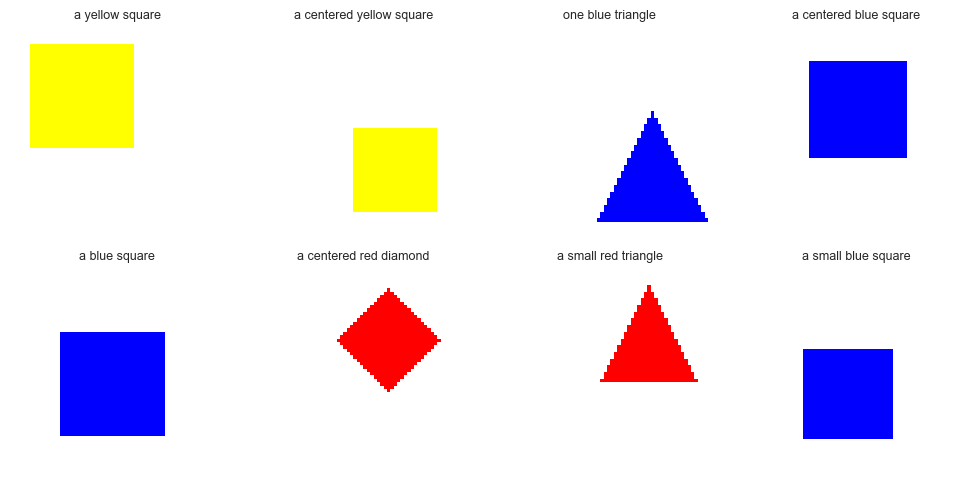

In [2]:
# ------------------------------
# 这段代码做什么：
# 1. 生成一个彩色几何图形数据集
# 2. 每张图都配一个简短文本描述，形成最小图文对
# ------------------------------
colors = ["red", "blue", "green", "yellow"]
shapes = ["circle", "square", "triangle", "diamond"]
templates = [
    "a {color} {shape}",
    "one {color} {shape}",
    "a small {color} {shape}",
    "a centered {color} {shape}",
]


def render_shape(shape, color, size=64):
    img = Image.new("RGB", (size, size), "white")
    draw = ImageDraw.Draw(img)
    cx = random.randint(18, 46)
    cy = random.randint(18, 46)
    radius = random.randint(12, 18)

    if shape == "circle":
        draw.ellipse((cx - radius, cy - radius, cx + radius, cy + radius), fill=color)
    elif shape == "square":
        draw.rectangle((cx - radius, cy - radius, cx + radius, cy + radius), fill=color)
    elif shape == "triangle":
        draw.polygon([(cx, cy - radius), (cx - radius, cy + radius), (cx + radius, cy + radius)], fill=color)
    elif shape == "diamond":
        draw.polygon([(cx, cy - radius), (cx - radius, cy), (cx, cy + radius), (cx + radius, cy)], fill=color)

    arr = np.asarray(img).astype("float32") / 255.0
    return torch.tensor(arr).permute(2, 0, 1)


toy_samples = []
for color in colors:
    for shape in shapes:
        for _ in range(120):
            caption = random.choice(templates).format(color=color, shape=shape)
            label = f"{color} {shape}"
            toy_samples.append((render_shape(shape, color), caption, label))

random.shuffle(toy_samples)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, (image, caption, label) in zip(axes.flat, toy_samples[:8]):
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(caption, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [3]:
# ------------------------------
# 这段代码做什么：
# 1. 构造最小 tokenizer 和 Dataset
# 2. 把图像、token ids 和语义标签组织到一起
# ------------------------------
vocab = sorted(set(" ".join(caption for _, caption, _ in toy_samples).split()))
word2idx = {word: i + 1 for i, word in enumerate(vocab)}  # 0 留给 padding


def tokenize(text, max_len=6):
    ids = [word2idx[word] for word in text.split()]
    ids = ids[:max_len] + [0] * max(0, max_len - len(ids))
    return torch.tensor(ids, dtype=torch.long)


class ShapeCaptionDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image, caption, label = self.samples[idx]
        return image, tokenize(caption), caption, label


full_ds = ShapeCaptionDataset(toy_samples)
train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size
train_ds, val_ds = random_split(
    full_ds,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=128, shuffle=False)

print("vocab size =", len(vocab))
print("train size =", len(train_ds), "val size =", len(val_ds))

vocab size = 12
train size = 1536 val size = 384


### 这里要强调什么

这一小节看起来只是“造数据”，但它其实解决了课堂上的一个关键难点：

- 什么叫图文配对？
- 什么叫共享语义空间？
- 相似度矩阵里的“正例”和“负例”到底是谁？

这些概念在自然语言描述很复杂的数据集上容易被噪声盖住，但在彩色几何图形里会非常清楚。

In [4]:
# ------------------------------
# 这段代码做什么：
# 1. 定义一个最小 image encoder 和 text encoder
# 2. 用对比学习目标训练它们进入同一个语义空间
# ------------------------------
class TinyImageEncoder(nn.Module):
    def __init__(self, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(24, 48, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.proj = nn.Linear(96, embed_dim)

    def forward(self, images):
        # 图像经过 CNN 后被压成一个全局向量
        feats = self.net(images).flatten(1)
        return self.proj(feats)


class TinyTextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)
        self.proj = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, token_ids):
        # 最小实现里直接对 token embedding 求平均，得到句子表示
        token_embed = self.embedding(token_ids)
        mask = (token_ids != 0).unsqueeze(-1)
        pooled = (token_embed * mask).sum(1) / mask.sum(1).clamp(min=1)
        return self.proj(pooled)


class TinyCLIP(nn.Module):
    def __init__(self, vocab_size, embed_dim=64):
        super().__init__()
        self.image_encoder = TinyImageEncoder(embed_dim=embed_dim)
        self.text_encoder = TinyTextEncoder(vocab_size=vocab_size, embed_dim=embed_dim)
        self.logit_scale = nn.Parameter(torch.tensor(math.log(1 / 0.07)))

    def forward(self, images, token_ids):
        image_embeds = F.normalize(self.image_encoder(images), dim=1)
        text_embeds = F.normalize(self.text_encoder(token_ids), dim=1)
        scale = self.logit_scale.exp().clamp(max=100)
        logits = image_embeds @ text_embeds.T * scale
        return logits, image_embeds, text_embeds


toy_clip = TinyCLIP(vocab_size=len(vocab), embed_dim=64).to(device)
toy_opt = torch.optim.Adam(toy_clip.parameters(), lr=1e-3)


def clip_loss(logits):
    # 正例在对角线上：第 i 张图和第 i 条文本互相对应
    labels = torch.arange(len(logits), device=logits.device)
    loss_i = F.cross_entropy(logits, labels)
    loss_t = F.cross_entropy(logits.T, labels)
    return (loss_i + loss_t) / 2


print(toy_clip)

TinyCLIP(
  (image_encoder): TinyImageEncoder(
    (net): Sequential(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): AdaptiveAvgPool2d(output_size=1)
    )
    (proj): Linear(in_features=96, out_features=64, bias=True)
  )
  (text_encoder): TinyTextEncoder(
    (embedding): Embedding(13, 64, padding_idx=0)
    (proj): Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )
  )
)


In [5]:
# ------------------------------
# 这段代码做什么：
# 1. 训练 toy CLIP
# 2. 观察对比学习损失是否下降
# ------------------------------
toy_losses = []

for epoch in range(12):
    batch_losses = []
    toy_clip.train()
    for images, token_ids, captions, labels in train_dl:
        images = images.to(device)
        token_ids = token_ids.to(device)

        logits, _, _ = toy_clip(images, token_ids)
        loss = clip_loss(logits)

        toy_opt.zero_grad()
        loss.backward()
        toy_opt.step()
        batch_losses.append(float(loss.item()))

    epoch_loss = float(np.mean(batch_losses))
    toy_losses.append(epoch_loss)

    if epoch in [0, 3, 7, 11]:
        print(f"Epoch {epoch + 1}: loss={epoch_loss:.4f}")

Epoch 1: loss=3.5031


Epoch 4: loss=2.3875


Epoch 8: loss=1.6284


Epoch 12: loss=1.5175


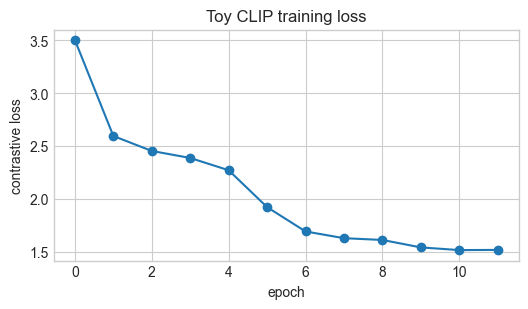

In [6]:
# ------------------------------
# 这段代码做什么：
# 1. 画出 toy CLIP 的训练 loss
# 2. 看看图文对齐是不是在逐步变好
# ------------------------------
plt.figure(figsize=(6, 3))
plt.plot(toy_losses, marker="o")
plt.title("Toy CLIP training loss")
plt.xlabel("epoch")
plt.ylabel("contrastive loss")
plt.show()

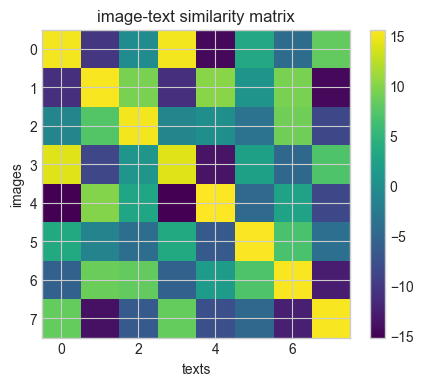

In [7]:
# ------------------------------
# 这段代码做什么：
# 1. 可视化一个 mini-batch 的相似度矩阵
# 2. 看看对角线是否逐渐变亮
# ------------------------------
toy_clip.eval()
images, token_ids, captions, labels = next(iter(val_dl))
images = images[:8].to(device)
token_ids = token_ids[:8].to(device)

with torch.no_grad():
    logits, image_embeds, text_embeds = toy_clip(images, token_ids)
    sim = logits.cpu().numpy()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim, cmap="viridis")
ax.set_title("image-text similarity matrix")
ax.set_xlabel("texts")
ax.set_ylabel("images")
fig.colorbar(im, ax=ax)
plt.show()

In [8]:
# ------------------------------
# 这段代码做什么：
# 1. 用一组文本提示词做 zero-shot 分类
# 2. 看 toy CLIP 是否已经学会颜色 + 形状的语义对齐
# ------------------------------
combo_prompts = [f"a {color} {shape}" for color in colors for shape in shapes]
combo_token_ids = torch.stack([tokenize(text) for text in combo_prompts]).to(device)

with torch.no_grad():
    prompt_embeds = F.normalize(toy_clip.text_encoder(combo_token_ids), dim=1)

    total = 0
    correct = 0
    for images, token_ids, captions, labels in val_dl:
        images = images.to(device)
        image_embeds = F.normalize(toy_clip.image_encoder(images), dim=1)
        pred = (image_embeds @ prompt_embeds.T).argmax(dim=1)
        pred_labels = [combo_prompts[i].replace("a ", "") for i in pred.tolist()]
        correct += sum(int(p == y) for p, y in zip(pred_labels, labels))
        total += len(labels)

print("toy zero-shot accuracy =", round(correct / total, 3))

toy zero-shot accuracy = 1.0


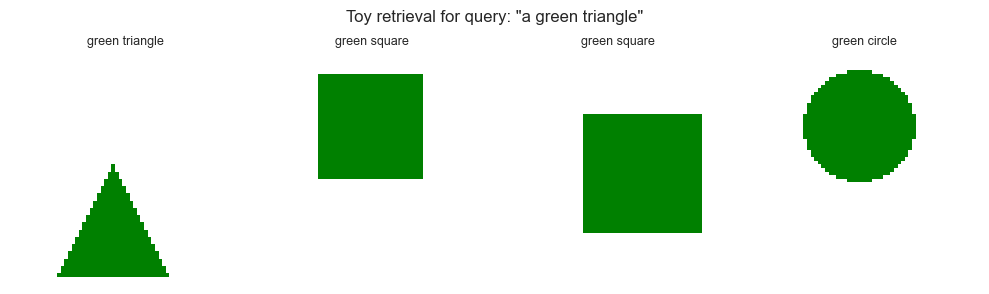

In [9]:
# ------------------------------
# 这段代码做什么：
# 1. 给一个文本查询，从 toy gallery 里检索最相近图像
# 2. 对应 text-to-image retrieval
# ------------------------------
query_text = "a green triangle"
gallery_images, _, gallery_captions, gallery_labels = next(iter(val_dl))
gallery_images = gallery_images[:24].to(device)

with torch.no_grad():
    gallery_embeds = F.normalize(toy_clip.image_encoder(gallery_images), dim=1)
    query_embed = F.normalize(toy_clip.text_encoder(tokenize(query_text).unsqueeze(0).to(device)), dim=1)
    scores = (gallery_embeds @ query_embed.T).squeeze(1)
    topk = scores.topk(4).indices.cpu().tolist()

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for ax, idx in zip(axes, topk):
    ax.imshow(gallery_images[idx].cpu().permute(1, 2, 0))
    ax.set_title(gallery_labels[idx], fontsize=9)
    ax.axis("off")
plt.suptitle(f'Toy retrieval for query: "{query_text}"')
plt.tight_layout()
plt.show()

### 这一部分真正要带走的不是“图形识别”

toy CLIP 的价值在于把下面三件事讲得很清楚：

1. 图像和文本都被投到同一个向量空间里
2. zero-shot 分类本质上是“拿图像去比一组文本提示词”
3. 检索本质上也是“跨模态相似度排序”

到这里再切到真正的预训练 CLIP，概念就不会跳得太突然。

# Part 3. 预训练 OpenAI CLIP：zero-shot、检索和多选式 VQA

现在把视角从 toy 数据换到真实模型。  
原书里的 `OpenAI_clip.ipynb` 用的是 OpenAI 官方 repo，这里改成 `transformers` 版本，原因很简单：

- 环境更干净
- CPU 上也能直接跑
- 更方便和后面的 Hugging Face 生态衔接

<img src="images/lesson6_multimodal/zero_shot_pipeline.png" width="980">

### zero-shot classification 的关键词

- 不是“模型突然会分类了”
- 而是“图像向量拿去和一组文本向量比较”
- 提示词模板会影响结果，因为文本端的表示会变化

In [10]:
# ------------------------------
# 这段代码做什么：
# 1. 载入预训练 OpenAI CLIP
# 2. 准备 CIFAR10 作为真实图像演示数据
# ------------------------------
cifar_val = datasets.CIFAR10(root="cifar_data", train=False, download=True)
cifar_classes = cifar_val.classes

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32", use_fast=False)
clip_model.eval()

print("num classes =", len(cifar_classes))
print("classes =", cifar_classes)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 57788.38it/s]


CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


num classes = 10
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


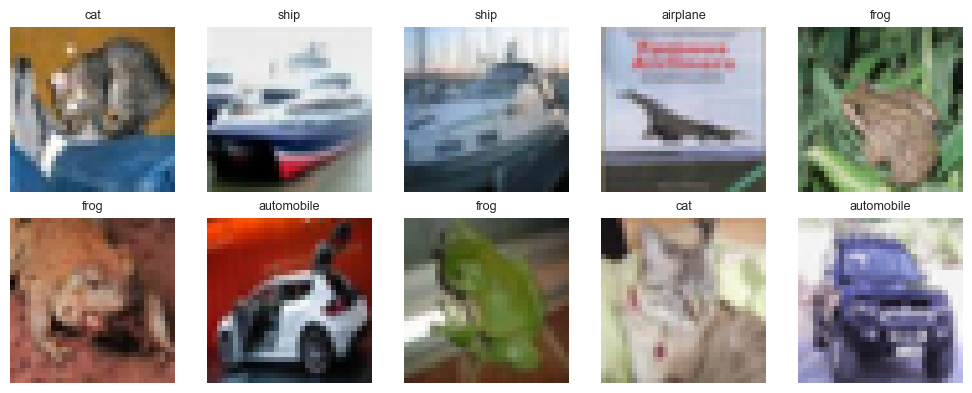

In [11]:
# ------------------------------
# 这段代码做什么：
# 1. 先看几张 CIFAR10 样本图
# 2. 为后面的 zero-shot 和检索做参照
# ------------------------------
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.flat, range(10)):
    image, label = cifar_val[idx]
    ax.imshow(image)
    ax.set_title(cifar_classes[label], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [12]:
# ------------------------------
# 这段代码做什么：
# 1. 比较两种提示词模板
# 2. 说明 prompt engineering 为什么会影响 zero-shot 效果
# ------------------------------
eval_images = [cifar_val[i][0] for i in range(100)]
eval_true = [cifar_classes[cifar_val[i][1]] for i in range(100)]

prompt_sets = {
    "label_only": list(cifar_classes),
    "photo_prompt": [f"a photo of a {name}" for name in cifar_classes],
}

for prompt_name, texts in prompt_sets.items():
    inputs = clip_processor(text=texts, images=eval_images, return_tensors="pt", padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        probs = clip_model(**inputs).logits_per_image.softmax(dim=1)

    preds = [cifar_classes[i] for i in probs.argmax(dim=1).tolist()]
    acc = sum(int(p == y) for p, y in zip(preds, eval_true)) / len(eval_true)
    print(f"{prompt_name}: acc={acc:.3f}")

label_only: acc=0.870


photo_prompt: acc=0.910



true = cat
         cat: 0.415
         dog: 0.211
        ship: 0.104

true = ship
        ship: 0.989
  automobile: 0.007
    airplane: 0.002

true = airplane
    airplane: 0.568
        bird: 0.336
  automobile: 0.049

true = cat
         cat: 0.953
         dog: 0.032
       horse: 0.004

true = dog
         dog: 0.772
         cat: 0.189
       horse: 0.015


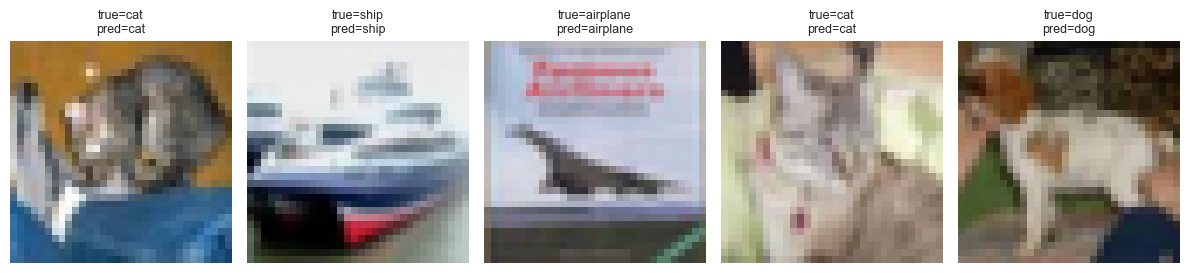

In [13]:
# ------------------------------
# 这段代码做什么：
# 1. 对几张真实图像做 zero-shot 分类
# 2. 打印 top-3 文本提示词概率
# ------------------------------
sample_indices = [0, 1, 3, 8, 12]
sample_images = [cifar_val[i][0] for i in sample_indices]
sample_true = [cifar_classes[cifar_val[i][1]] for i in sample_indices]
candidate_texts = [f"a photo of a {name}" for name in cifar_classes]

inputs = clip_processor(text=candidate_texts, images=sample_images, return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    probs = clip_model(**inputs).logits_per_image.softmax(dim=1).cpu()

fig, axes = plt.subplots(1, len(sample_images), figsize=(12, 3))
for ax, image, true_label, prob in zip(axes, sample_images, sample_true, probs):
    top_vals, top_idx = prob.topk(3)
    pred_name = cifar_classes[int(top_idx[0])]
    ax.imshow(image)
    ax.set_title(f"true={true_label}\npred={pred_name}", fontsize=9)
    ax.axis("off")

    print("\ntrue =", true_label)
    for value, idx in zip(top_vals.tolist(), top_idx.tolist()):
        print(f"  {cifar_classes[idx]:>10s}: {value:.3f}")

plt.tight_layout()
plt.show()

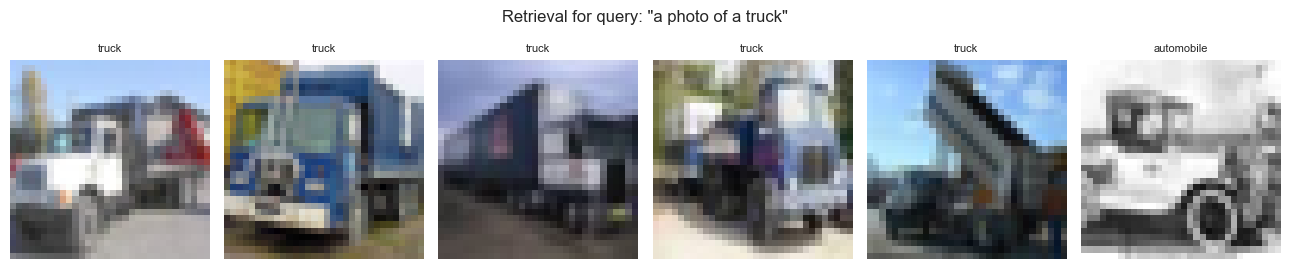

In [14]:
# ------------------------------
# 这段代码做什么：
# 1. 用文本查询在小型图像库里做检索
# 2. 观察 CLIP 的 image-text retrieval 能力
# ------------------------------
gallery_indices = list(range(60))
gallery_images = [cifar_val[i][0] for i in gallery_indices]
gallery_labels = [cifar_classes[cifar_val[i][1]] for i in gallery_indices]
query = "a photo of a truck"

inputs = clip_processor(text=[query], images=gallery_images, return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    scores = clip_model(**inputs).logits_per_text[0].cpu()

top_idx = scores.topk(6).indices.tolist()

fig, axes = plt.subplots(1, 6, figsize=(13, 2.8))
for ax, idx in zip(axes, top_idx):
    ax.imshow(gallery_images[idx])
    ax.set_title(gallery_labels[idx], fontsize=8)
    ax.axis("off")
plt.suptitle(f'Retrieval for query: "{query}"')
plt.tight_layout()
plt.show()

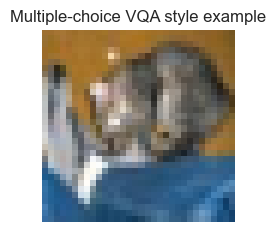

     the answer is cat: 0.553
     the answer is dog: 0.179
    the answer is bird: 0.207
   the answer is horse: 0.061


In [15]:
# ------------------------------
# 这段代码做什么：
# 1. 用 CLIP 做一个“多选式 VQA”示意
# 2. 说明它本质上是答案排序，而不是自由生成
# ------------------------------
cat_idx = next(i for i, (_, y) in enumerate(cifar_val) if cifar_classes[y] == "cat")
qa_image, _ = cifar_val[cat_idx]
answer_choices = [
    "the answer is cat",
    "the answer is dog",
    "the answer is bird",
    "the answer is horse",
]

inputs = clip_processor(text=answer_choices, images=[qa_image], return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    answer_probs = clip_model(**inputs).logits_per_image.softmax(dim=1)[0].cpu()

plt.figure(figsize=(2.5, 2.5))
plt.imshow(qa_image)
plt.axis("off")
plt.title("Multiple-choice VQA style example")
plt.show()

for choice, prob in zip(answer_choices, answer_probs.tolist()):
    print(f"{choice:>22s}: {prob:.3f}")

### 这里要明确区分两件事

CLIP 确实可以做一些“像问答”的事情，但这里的机制仍然是：

- 给图像编码
- 给候选答案编码
- 做相似度排序

所以它更像 **answer selection**，而不是现代视觉语言模型那种自由生成式 VQA。

# Part 4. 从 CLIP 走到 ImageBind

如果 CLIP 的关键思想是“把图像和文本放进同一个空间”，那么一个自然的问题就是：

> **这个空间能不能不只接图像和文本，还接音频、深度、热成像甚至 IMU？**

ImageBind 的回答是：可以，而且不一定要求所有模态都两两成对出现。

<img src="images/lesson6_multimodal/imagebind_map.png" width="980">

### 为什么这里值得讲一下 ImageBind

因为它把 CLIP 的路线再往前推了一步：

- CLIP：`vision <-> text`
- ImageBind：`vision <-> text <-> audio <-> depth <-> thermal <-> IMU`

所以这一节课到这里，逻辑应该收得很自然：

> **CLIP 不是多模态学习的终点，而是“共享语义空间”这条路线里最经典的一步。**

In [16]:
# ------------------------------
# 这段代码做什么：
# 1. 给出一个 ImageBind 的最小可选演示入口
# 2. 默认不运行，以免课堂环境被安装和大模型拖慢
# ------------------------------
if RUN_IMAGEBIND:
    print("请参考原书的 Chapter16/ImageBind.ipynb 安装依赖并执行。")
    print("这一格保留的目的是把 ImageBind 放进课程主线，而不是在 CPU 课堂里强行跑大模型。")
else:
    print("跳过 ImageBind 实际推理。")
    print("默认讲解重点放在 CLIP 的共享空间思想，以及它如何扩展到更多模态。")

跳过 ImageBind 实际推理。
默认讲解重点放在 CLIP 的共享空间思想，以及它如何扩展到更多模态。


# 小结

这一讲最后可以收成六句话：

1. 多模态模型的核心目标，是把不同模态映射到同一个语义空间里。
2. CLIP 通过图文对比学习，让图像和文本的相似度变成了可直接使用的推理信号。
3. zero-shot 分类，本质上是“图像 vs 一组文本提示词”的相似度比较。
4. 图文检索和多选式问答，本质上也是跨模态排序问题。
5. prompt 模板会影响文本表示，所以 prompt engineering 会影响 zero-shot 效果。
6. ImageBind 延续了 CLIP 的思路，把共享空间扩展到了更多模态。

## 课后可以继续追问的三个问题

- 如果 toy CLIP 只在有限模板上训练，它的泛化会卡在哪？
- 为什么 CLIP 能做多选式 VQA，却不擅长自由生成答案？
- ImageBind 如果继续往前走，和现代 VLM / 多模态大模型之间是什么关系？